In [2]:
import numpy  as  np 
import pandas as  pd 
import graphviz 

from   sklearn                  import  tree
from   sklearn.tree             import  DecisionTreeClassifier
from   sklearn.metrics          import  confusion_matrix
from   sklearn.metrics          import  classification_report
from   sklearn.model_selection  import  train_test_split

In [ ]:
dataset = pd.read_csv('File/tennis.csv') 
df = pd.DataFrame(dataset) 
df

,Wind,Temp,Outlook,Humidity,Action
0,weak,Hot,sunny,high,play
1,strong,Hot,sunny,high,play
2,weak,Hot,rainy,high,stay
3,weak,Mild,overcast,high,play
4,strong,Cold,rainy,normal,stay
5,weak,Cold,overcast,normal,play
6,strong,Cold,rainy,normal,stay
7,weak,Mild,sunny,normal,play
8,weak,Cold,sunny,normal,play
9,strong,Mild,overcast,normal,play


In [4]:
df['Wind']     = df['Wind'].map({'weak':0, 'strong':1})
df['Temp']     = df['Temp'].map({'Cold':0, 'Mild':1, 'Hot':2})
df['Outlook']  = df['Outlook'].map({'overcast':0, 'rainy':1, 'sunny':2})
df['Humidity'] = df['Humidity'].map({'normal':0, 'high':1})

df

,Wind,Temp,Outlook,Humidity,Action
0,0,2,2,1,play
1,1,2,2,1,play
2,0,2,1,1,stay
3,0,1,0,1,play
4,1,0,1,0,stay
5,0,0,0,0,play
6,1,0,1,0,stay
7,0,1,2,0,play
8,0,0,2,0,play
9,1,1,0,0,play


In [5]:
X = df.drop(['Action'], axis=1)  
y = df['Action'] 

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)  

In [50]:
X_test

,Wind,Temp,Outlook,Humidity
9,1,1,0,0
11,1,1,1,1
0,0,2,2,1
12,0,2,0,0
5,0,0,0,0


In [55]:
clf = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=27)     # criterion='gini',max_depth=3,random_state=0

In [56]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=27)

In [57]:
y_pred = clf.predict(X_test)
y_pred

array(['play', 'play', 'play', 'play', 'play'], dtype=object)

In [58]:
y_test == y_pred

9      True
11    False
0      True
12     True
5      True
Name: Action, dtype: bool

In [59]:
confusion_matrix(y_test, y_pred)

array([[4, 0],
       [1, 0]])

In [60]:
print(classification_report(y_test, y_pred))  

              precision    recall  f1-score   support

        play       0.80      1.00      0.89         4
        stay       0.00      0.00      0.00         1

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



C:\Users\Rouzb\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Rouzb\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Rouzb\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

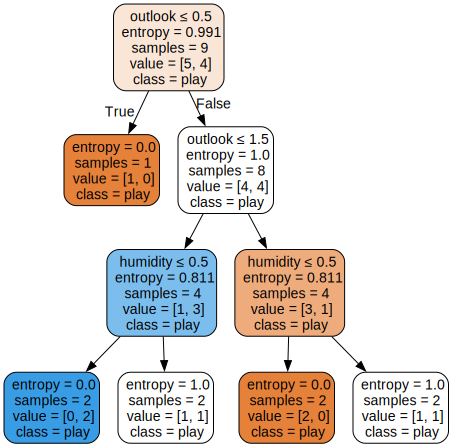

In [61]:
d = tree.export_graphviz(clf, 
                         class_names=y, 
                         feature_names=['wind','temp','outlook','humidity'],
                         filled=True, rounded=True, special_characters=True
                         )
graphviz.Source(d)